In [1]:
!pip install kagglehub tensorflow matplotlib seaborn scikit-learn

In [2]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
path = kagglehub.dataset_download(
    "serenaraju/yawn-eye-dataset-new"
)

print("Dataset path:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'yawn-eye-dataset-new' dataset.
Dataset path: /kaggle/input/yawn-eye-dataset-new
['dataset_new']


In [4]:
data_dir = path
print(os.listdir(data_dir))

['dataset_new']


In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [6]:
train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(227,227),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 2320 images belonging to 1 classes.


In [7]:
valid_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(227,227),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 580 images belonging to 1 classes.


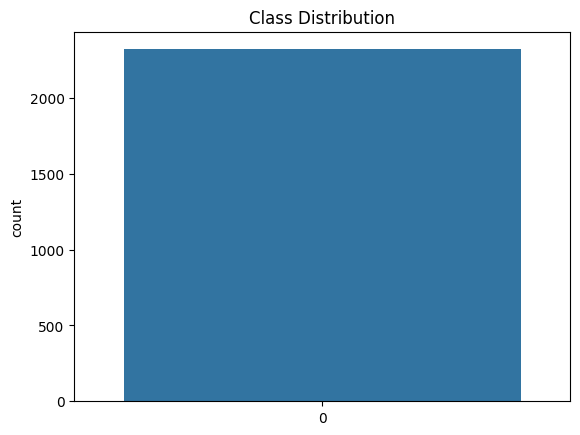

In [8]:
sns.countplot(x=train_data.classes)
plt.title("Class Distribution")
plt.show()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# AlexNet style
model.add(Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(227,227,3)))
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

model.add(Conv2D(256, (5,5), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

model.add(Conv2D(384, (3,3), activation='relu', padding='same'))
model.add(Conv2D(384, (3,3), activation='relu', padding='same'))
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

model.add(Flatten())

model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,285,441 (222.34 MB)

 Trainable params: 58,285,441 (222.34 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=valid_data,
    steps_per_epoch=train_data.samples // train_data.batch_size,
    validation_steps=valid_data.samples // valid_data.batch_size
)

Epoch 1/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 381ms/step - accuracy: 0.9873 - loss: 0.0100 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
 1/72 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 1.0000 - loss: 0.0000e+00

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


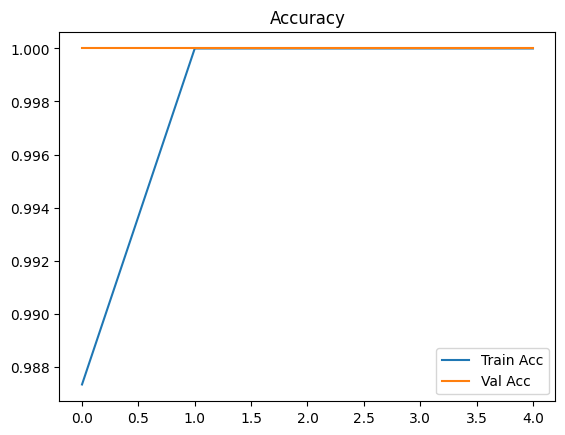

In [12]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")
plt.show()

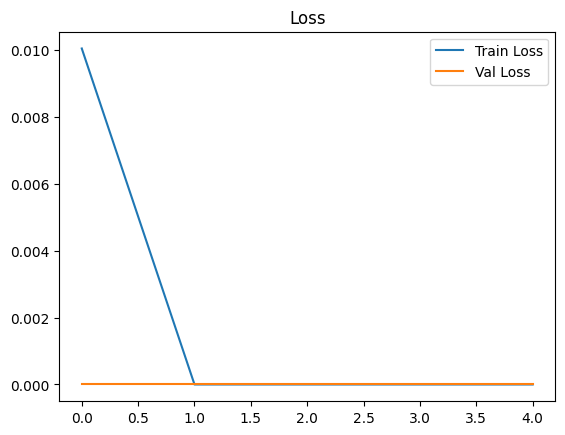

In [14]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [15]:
preds = model.predict(valid_data)
preds = (preds > 0.5).astype(int)

true_labels = valid_data.classes[:len(preds)]

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step


In [16]:
print(classification_report(true_labels, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       580

    accuracy                           1.00       580
   macro avg       1.00      1.00      1.00       580
weighted avg       1.00      1.00      1.00       580



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


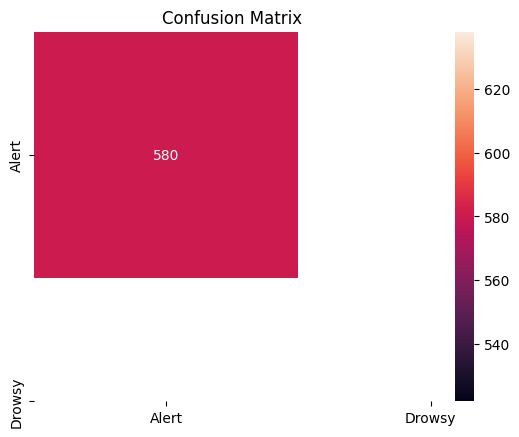

In [17]:
cm = confusion_matrix(true_labels, preds)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Alert','Drowsy'],
            yticklabels=['Alert','Drowsy'])

plt.title("Confusion Matrix")
plt.show()

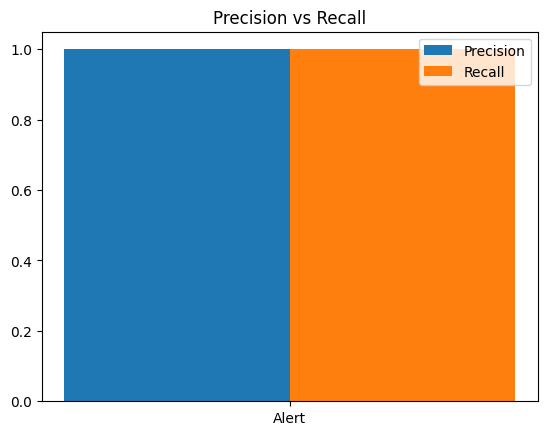

In [19]:
precision = []
recall = []

report = classification_report(true_labels, preds, output_dict=True)

# Get the actual class labels from the report (e.g., '0', '1', etc.)
# Filter out non-numeric keys like 'accuracy', 'macro avg', 'weighted avg'
actual_classes = sorted([k for k in report.keys() if k.isdigit()])

# Append precision and recall for each actual class
for class_key in actual_classes:
    precision.append(report[class_key]['precision'])
    recall.append(report[class_key]['recall'])

# Map actual_classes to the human-readable labels
# Assuming '0' -> 'Alert', '1' -> 'Drowsy'
display_labels_map = {'0': 'Alert', '1': 'Drowsy'}
labels_for_plot = [display_labels_map[c] for c in actual_classes]

x = np.arange(len(labels_for_plot))

plt.bar(x-0.2, precision, 0.4, label='Precision')
plt.bar(x+0.2, recall, 0.4, label='Recall')

plt.xticks(x, labels_for_plot)
plt.legend()
plt.title("Precision vs Recall")
plt.show()

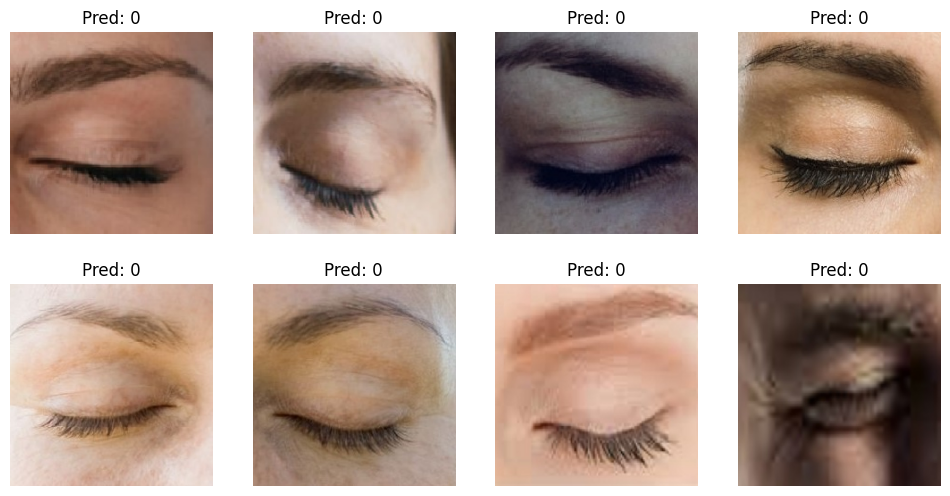

In [20]:
images, labels = next(valid_data)

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.title(f"Pred: {preds[i][0]}")
    plt.axis("off")

plt.show()